In [1]:
from pathlib import Path
from sqlalchemy import create_engine, inspect
import pandas as pd

# Connect to database. Source: https://www.kaggle.com/datasets/daniellopez01/credit-risk; originally from University of Chile
db_path = Path.cwd() / ("credit_data.db")
engine = create_engine(f"sqlite:///{db_path}")

# Inspect table and column names
inspector = inspect(engine)
table = inspector.get_table_names()[0] # The example db schema only contains one table, otherwise we would need to define its name here
print(inspector.get_table_names())

['credit']


In [2]:
# Inspect column names and types
columns = inspector.get_columns(table)
for column in columns:
    print(column["name"], column["type"])

checking_balance NVARCHAR(50)
months_loan_duration INTEGER
credit_history VARCHAR(50)
purpose VARCHAR(50)
amount INTEGER
savings_balance VARCHAR(50)
employment_duration NVARCHAR(50)
percent_of_income INTEGER
years_at_residence INTEGER
age INTEGER
other_credit VARCHAR(50)
housing VARCHAR(50)
existing_loans_count INTEGER
job VARCHAR(50)
dependents INTEGER
phone VARCHAR(50)
default VARCHAR(50)


In [3]:
# Query database and show all columns
query = f"""
SELECT
    *
FROM {table}
"""

# Execute the query and load the result into a pandas DataFrame. Display first five rows of DataFrame.
df = pd.read_sql(query, engine)
print(df.head())

  checking_balance  months_loan_duration credit_history               purpose  \
0           < 0 DM                     6       critical  furniture/appliances   
1       1 - 200 DM                    48           good  furniture/appliances   
2          unknown                    12       critical             education   
3           < 0 DM                    42           good  furniture/appliances   
4           < 0 DM                    24           poor                   car   

   amount savings_balance employment_duration  percent_of_income  \
0    1169         unknown           > 7 years                  4   
1    5951        < 100 DM         1 - 4 years                  2   
2    2096        < 100 DM         4 - 7 years                  2   
3    7882        < 100 DM         4 - 7 years                  2   
4    4870        < 100 DM         1 - 4 years                  3   

   years_at_residence  age other_credit housing  existing_loans_count  \
0                   4   67     

In [4]:
# Check for null values
print("Does dataframe contain null values? ", df.isna().values.any())
print("Columns containing null values: \n", df.isnull().sum())

Does dataframe contain null values?  False
Columns containing null values: 
 checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_duration     0
percent_of_income       0
years_at_residence      0
age                     0
other_credit            0
housing                 0
existing_loans_count    0
job                     0
dependents              0
phone                   0
default                 0
dtype: int64


In [5]:
# We are lucky - the dataset does not contain any null values!

# Check unique column values
for col in df.select_dtypes(include="object"):
    print(df[col].value_counts())
    print()

checking_balance
unknown       394
< 0 DM        274
1 - 200 DM    269
> 200 DM       63
Name: count, dtype: int64

credit_history
good         530
critical     293
poor          88
very good     49
perfect       40
Name: count, dtype: int64

purpose
furniture/appliances    473
car                     337
business                 97
education                59
renovations              22
car0                     12
Name: count, dtype: int64

savings_balance
< 100 DM         603
unknown          183
100 - 500 DM     103
500 - 1000 DM     63
> 1000 DM         48
Name: count, dtype: int64

employment_duration
1 - 4 years    339
> 7 years      253
4 - 7 years    174
< 1 year       172
unemployed      62
Name: count, dtype: int64

other_credit
none     814
bank     139
store     47
Name: count, dtype: int64

housing
own      713
rent     179
other    108
Name: count, dtype: int64

job
skilled       630
unskilled     200
management    148
unemployed     22
Name: count, dtype: int64

phone
no

In [6]:
# The "purpose" column contains the value categories "car" and "car0"
# In this example, we assume it to be a typo - and set "car0" to "car"
df["purpose"] = df["purpose"].replace("car0", "car")

# We check the unique values in the "purpose" column again:
print(df["purpose"].value_counts())

purpose
furniture/appliances    473
car                     349
business                 97
education                59
renovations              22
Name: count, dtype: int64


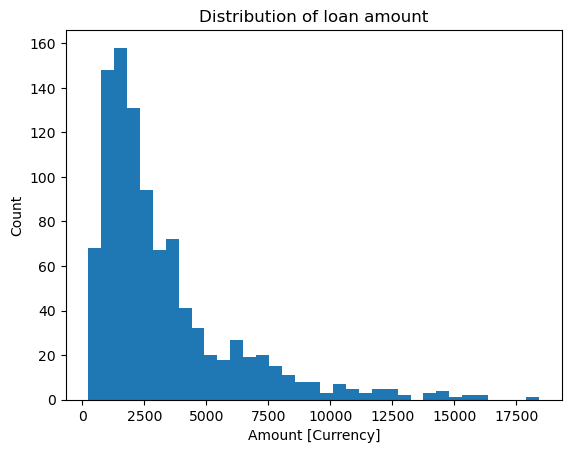

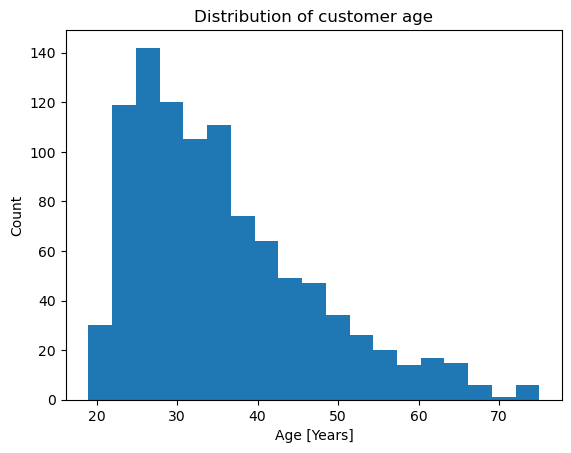

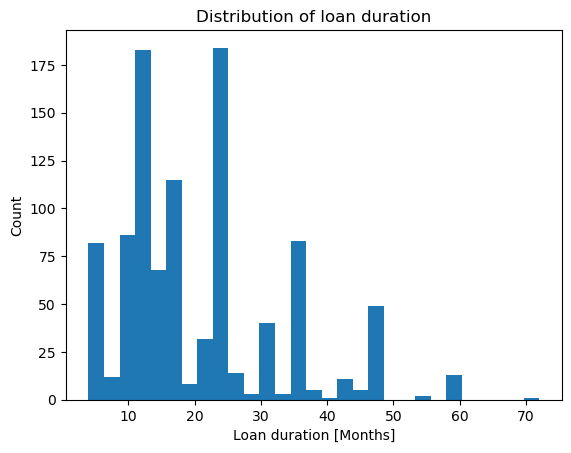

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Plot simple histogram of loan amounts to get overview
plt.hist(x = "amount", bins = 'auto', data = df)
plt.title("Distribution of loan amount")
plt.xlabel("Amount [Currency]")
plt.ylabel("Count")
plt.show()

plt.hist(x = "age", bins = 'auto', data = df)
plt.title("Distribution of customer age")
plt.xlabel("Age [Years]")
plt.ylabel("Count")
plt.show()

plt.hist(x = "months_loan_duration", bins = 'auto', data = df)
plt.title("Distribution of loan duration")
plt.xlabel("Loan duration [Months]")
plt.ylabel("Count")
plt.show()

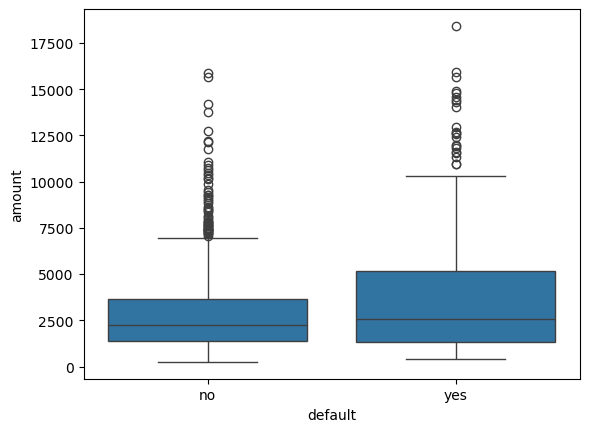

In [8]:
# Boxplot for loan amount by default status
sns.boxplot(
    data=df,
    x="default",
    y="amount"
)
plt.show()

In [9]:
# There seems to be a correlation: customers who default on their loan tend to have higher loan amounts
# Print crosstable for loan purpose by default status and group by to show percentages for yes/no by purpose category
print(pd.crosstab(df["purpose"], df["default"], margins = True))
print()
df.groupby("purpose")["default"].value_counts(normalize=True)

default                no  yes   All
purpose                             
business               63   34    97
car                   238  111   349
education              36   23    59
furniture/appliances  349  124   473
renovations            14    8    22
All                   700  300  1000



purpose               default
business              no         0.649485
                      yes        0.350515
car                   no         0.681948
                      yes        0.318052
education             no         0.610169
                      yes        0.389831
furniture/appliances  no         0.737844
                      yes        0.262156
renovations           no         0.636364
                      yes        0.363636
Name: proportion, dtype: float64

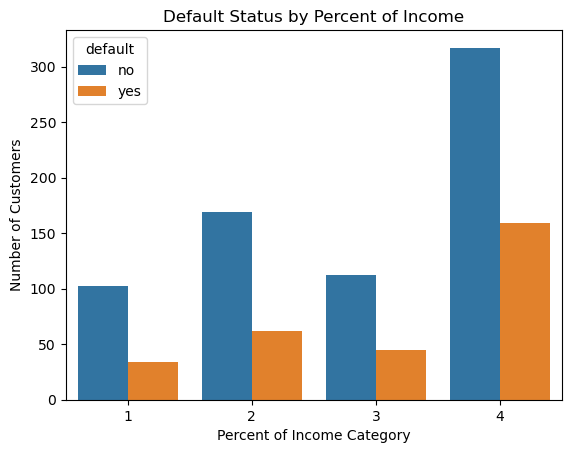

percent_of_income  default
1                  no         0.750000
                   yes        0.250000
2                  no         0.731602
                   yes        0.268398
3                  no         0.713376
                   yes        0.286624
4                  no         0.665966
                   yes        0.334034
Name: proportion, dtype: float64

In [10]:
sns.countplot(
    data=df,
    x="percent_of_income",
    hue="default"
)

plt.title("Default Status by Percent of Income")
plt.xlabel("Percent of Income Category")
plt.ylabel("Number of Customers")
plt.show()

#To enhance readability and interpretation of the plot, we can also print percentages for each column pair
df.groupby("percent_of_income")["default"].value_counts(normalize=True)

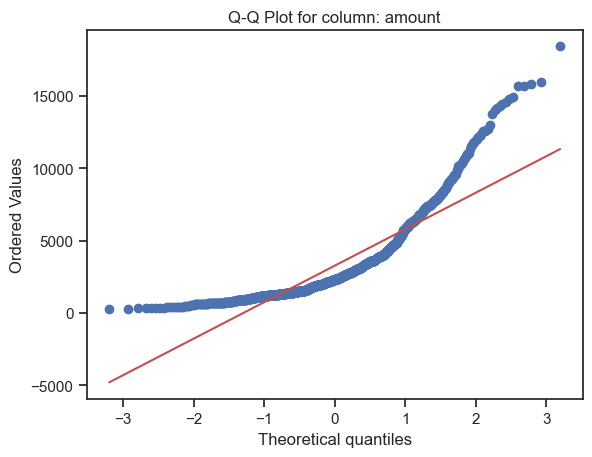

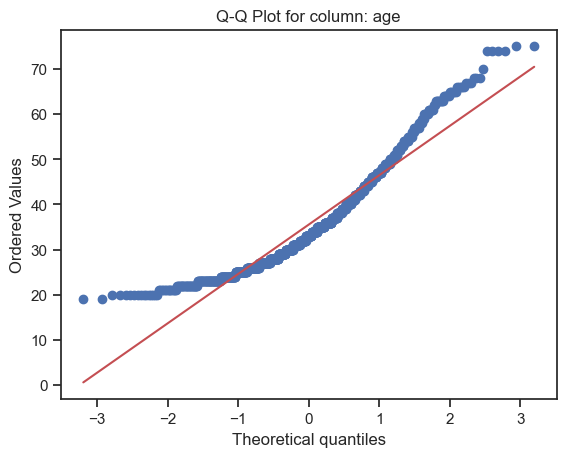

In [45]:
# We can see a correlation here: more defaults for higher percent of income payments
# Plot QQ-plot to check for normality and outliers
def create_qqplot(features: list):
    for feature in features:
        stats.probplot(df[feature], dist="norm", plot=plt)
        plt.title(f"Q-Q Plot for column: {feature}")
        plt.show()
create_qqplot(["amount", "age"])

In [12]:
# The histogram is right-skewed and the QQ-plots show a deviation from the supposed linear trend line.
# This strongly indicates non-normal distribution of the population.
# To quantify this, we can perform the Shapiro-Wilk test for normal distribution.
# In this case, the non-normality seems obvious, but I still want to do it for demonstration purposes.

relevance_threshold = 0.05
def perform_shapiro_wilk_test(features: list):
    for feature in features:
        stat, p_value = stats.shapiro(df[feature])
        print(f"p_value: {p_value}")
        print(f"Data for {feature}: fail to reject H0." if p_value > relevance_threshold else f"Data for {feature}: reject H0.")

from IPython.display import display, Markdown
display(Markdown(r"$H_0$: The data stems from a normal distribution. "
    r"$H_A$: The data does not stem from a normal distribution."))
perform_shapiro_wilk_test(["amount", "age"])

$H_0$: The data stems from a normal distribution. $H_A$: The data does not stem from a normal distribution.

p_value: 8.608545621331088e-34
Data for amount: reject H0.
p_value: 6.382098308916094e-23
Data for age: reject H0.


In [13]:
# Now we want to train a logistic regression model using scikit-learn
# We take all columns into account. Before that, we need to split categorical and numerical data for one-hot encoding
# Drop target variable ["default"] to avoid data leakage
num_features = df.drop(columns=["default"]).select_dtypes(exclude=['object'])
cat_features = df.drop(columns=["default"]).select_dtypes(include=['object'])

# One-hot encode the categorical features
cat_features_onehot = pd.get_dummies(cat_features)

# Concat one-hot encoded categorical with numerical features
df_oh = pd.concat([num_features, cat_features_onehot], axis=1)

# The "phone" column seems to be the least relevant by intuition and could possibly be omitted, but we still keep it here.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x = df_oh
y = df["default"]

# Transform string values for default into binary values
y = y.map({
    "no": 0,
    "yes": 1
})

In [14]:
import numpy as np

# Define train-test sets (60/40 ratio for train/test)
# We set stratify = y to maintain ratio of defaults to non defaults in both sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.4, random_state=1, stratify=y)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Create and fit the logistic regression model
model = LogisticRegression(solver="lbfgs", max_iter=100).fit(x_train_scaled, np.ravel(y_train))

# Print the models coefficients
print(model.coef_)

[[ 0.32655374  0.34399089  0.39011384 -0.01447831 -0.16026331  0.13834277
  -0.00466038  0.08496064  0.32760143 -0.02233321 -0.37250444 -0.34461552
   0.12225681  0.28081834  0.00323135  0.19287338 -0.03553     0.04549765
   0.15186905 -0.10629643  0.04330383  0.09165071  0.088566    0.13840616
  -0.21071872 -0.18499832  0.00672501 -0.18281963  0.16916916 -0.06464757
   0.12958009  0.1256132  -0.15218685  0.07636568 -0.09045709 -0.06309317
   0.14222251 -0.0638157   0.03626799  0.02621939  0.00344517  0.09023245
  -0.09023245]]


In [15]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

y_pred = model.predict(x_test_scaled)
y_prob = model.predict_proba(
    x_test_scaled
)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[243  37]
 [ 67  53]]
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       280
           1       0.59      0.44      0.50       120

    accuracy                           0.74       400
   macro avg       0.69      0.65      0.66       400
weighted avg       0.73      0.74      0.73       400

ROC-AUC: 0.7904166666666667


In [16]:
# The recall(1) for defaults is pretty low!
# Since defaults are very expensive for the bank, that would be the most important metric for our model!
# This is typical behavior for unbalanced datasets (more non-defaults than defaults)
# We can improve that by balancing out the class weights 
model_balanced = LogisticRegression(solver="lbfgs", max_iter=100, class_weight="balanced").fit(x_train_scaled, np.ravel(y_train))
y_pred_balanced = model_balanced.predict(x_test_scaled)
y_prob_balanced = model_balanced.predict_proba(
    x_test_scaled
)[:, 1]

print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test,y_pred_balanced))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))

[[198  82]
 [ 34  86]]
              precision    recall  f1-score   support

           0       0.85      0.71      0.77       280
           1       0.51      0.72      0.60       120

    accuracy                           0.71       400
   macro avg       0.68      0.71      0.69       400
weighted avg       0.75      0.71      0.72       400

ROC-AUC: 0.7857440476190476


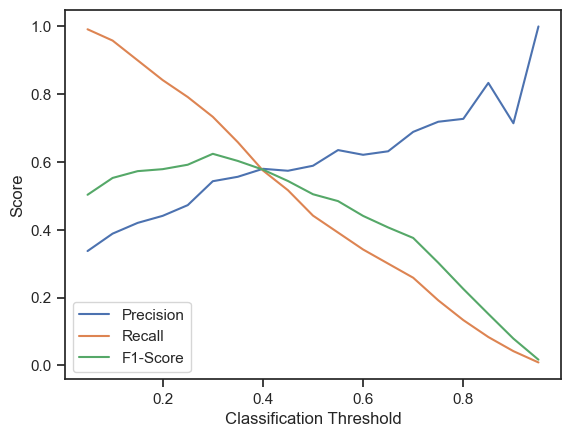

In [43]:
# the recall for defaults is indeed higher - 0.72 is a significant improvement over 0.44!
# as expected, this comes at a price: lower precision for 1 and f1-score for 0.

# we can also try to optimize the threshold for default detection
# to do so, we loop over different thresholds and plot precision, recall and f1-score
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

for threshold in np.arange(0.05, 0.96, 0.05):

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "f1": f1_score(
            y_test,
            y_pred_threshold
        )
    })

results_df = pd.DataFrame(results)

plt.plot(
    results_df["threshold"],
    results_df["precision"],
    label="Precision"
)

plt.plot(
    results_df["threshold"],
    results_df["recall"],
    label="Recall"
)

plt.plot(
    results_df["threshold"],
    results_df["f1"],
    label="F1-Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

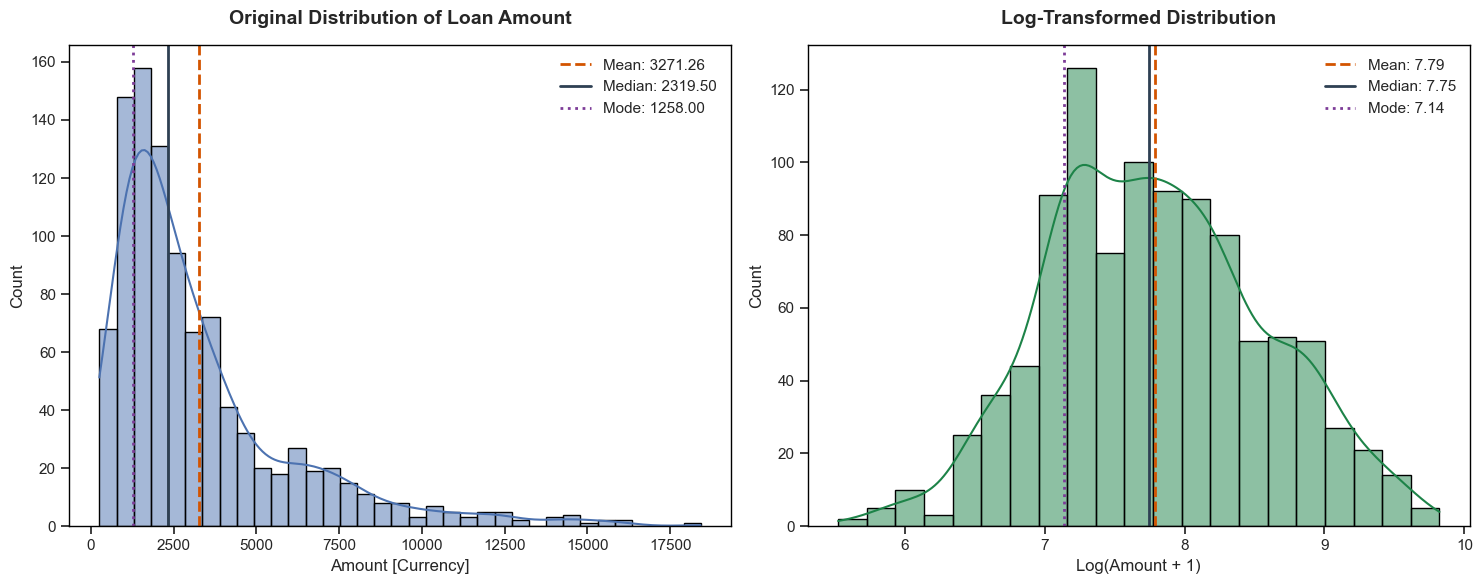

In [17]:
# Now we want to see the influence of data manipulation on our model
# We use a log+1 transformation on the 'amount' feature. A KDE-Histogram should look more like a bell curve after that
# We could later on use the transformed amount for a new logistic regression and compare

# Custom styling for clean, framed plots
sns.set_theme(style="ticks")
plt.rcParams["axes.spines.top"] = True
plt.rcParams["axes.spines.right"] = True

# 1. Create Log-Transformed Column
# Use np.log1p (log(1+x)) to safely handle any potential 0 values
df["log_amount"] = np.log1p(df["amount"])

# 2. Setup Figure and Subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Helper function to compute mode safely
def get_mode(series):
    return series.mode().iloc[0] if not series.mode().empty else np.nan

# Define the columns, titles, labels, and specific colors for looping
plot_configs = [
    {
        "col": "amount", 
        "ax": axes[0], 
        "title": "Original Distribution of Loan Amount", 
        "xlabel": "Amount [Currency]",
        "color": "#4C72B0" # Deep Steel Blue
    },
    {
        "col": "log_amount", 
        "ax": axes[1], 
        "title": "Log-Transformed Distribution", 
        "xlabel": "Log(Amount + 1)",
        "color": "#1D8348"  # Dark Teal / Mint Green
    }
]

# 3. Plot Both Charts
for config in plot_configs:
    ax = config["ax"]
    col_data = df[config["col"]].dropna()
    
    # Calculate statistics
    mean_val = col_data.mean()
    median_val = col_data.median()
    mode_val = get_mode(col_data)
    
    # Plot KDE & Histogram with custom colors and visible frame edges
    sns.histplot(
        data=df, 
        x=config["col"], 
        kde=True, 
        bins="auto", 
        ax=ax, 
        edgecolor="black", 
        linewidth=1,
        color=config["color"]  # Dynamically applies the color from config
    )
    
    # Draw statistical lines (using contrast colors)
    ax.axvline(mean_val, color="#D35400", linestyle="--", linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color="#2E4053", linestyle="-", linewidth=2, label=f'Median: {median_val:.2f}')
    if not np.isnan(mode_val):
        ax.axvline(mode_val, color="#7D3C98", linestyle=":", linewidth=2, label=f'Mode: {mode_val:.2f}')
    
    # Titles, labels, and framing
    ax.set_title(config["title"], fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel(config["xlabel"], fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.legend(frameon=True, facecolor="white", edgecolor="none")
    
    # Explicitly ensure all four borders (spines) are visible
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [ ]:
# Work in progress ... setting up another log-reg with the transformed amount and compare recall/roc-auc?